# Wildfire Risk Prediction — California (2018–2020)

**Goal:** turn multi-source daily weather and dryness data on a 10 km California grid into a forward-looking **wildfire risk map** (red / yellow / green).

This is the modelling notebook. It runs end-to-end:

1. **Data & temporal split** — train on the past, test on the future.
2. **Algorithm screening** — a fast LazyPredict benchmark to choose a model family.
3. **Baselines + honest evaluation** — four models on the full data, judged at the true 0.3% fire rate.
4. **Hyperparameter tuning** — Optuna optimises XGBoost for PR-AUC.
5. **From probabilities to a risk map** — calibrate the scores, then tier them red/yellow/green.
6. **Summary & next steps.**

**Framing up front:** fires are extreme rare events (~0.3% of cell-days). No model can reliably output a yes/no "fire today." What it *can* do is **rank** cells by danger and report an honest **probability** — so we build a risk *tracker*, not a hard classifier. The primary metric is **PR-AUC** (precision–recall area), which stays honest under heavy imbalance.

## 1. Data & Temporal Split

We load the cleaned dataset (one row per grid-cell per day) and split it **by time**: train on **2018–2019**, test on **2020**. A temporal split mirrors production — the model always predicts the future from the past — and avoids the leakage a random split would create between adjacent days and neighbouring cells.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

df = pd.read_parquet('../data/processed/california_dataset.parquet')

drop_cols = ['grid_id', 'date', 'has_fire', 'fire_count', 'total_acres']
feature_cols = [c for c in df.columns if c not in drop_cols]

train = df[df['date'].dt.year.isin([2018, 2019])]
test  = df[df['date'].dt.year == 2020]
X_train, y_train = train[feature_cols], train['has_fire']
X_test,  y_test  = test[feature_cols],  test['has_fire']

print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols  |  {len(feature_cols)} features')
print(f'Train 2018-2019: {len(X_train):,} rows  ({y_train.sum():,} fires, {y_train.mean()*100:.3f}%)')
print(f'Test  2020:      {len(X_test):,} rows  ({y_test.sum():,} fires, {y_test.mean()*100:.3f}%)')

Dataset: 4,020,128 rows x 33 cols  |  28 features
Train 2018-2019: 2,677,640 rows  (6,775 fires, 0.253%)
Test  2020:      1,342,488 rows  (4,185 fires, 0.312%)


## 2. Algorithm Screening (LazyPredict)

Before committing, we benchmark ~25 classifiers with default settings to see which *family* fits this signal. Four million rows is too large for several of them, so we screen on a **balanced 10:1 subsample** (all fire days + 10× as many non-fire days), keeping the run fast while preserving the relative ranking.

In [2]:
from lazypredict.Supervised import LazyClassifier, CLASSIFIERS

def balanced_subsample(frame, ratio=10, seed=42):
    fire = frame[frame['has_fire'] == 1]
    nofire = frame[frame['has_fire'] == 0].sample(n=len(fire) * ratio, random_state=seed)
    return pd.concat([fire, nofire]).sample(frac=1, random_state=seed)

train_sub, test_sub = balanced_subsample(train), balanced_subsample(test)
Xtr_s, ytr_s = train_sub[feature_cols], train_sub['has_fire']
Xte_s, yte_s = test_sub[feature_cols],  test_sub['has_fire']

# Exclude estimators that build N x N matrices (~44 GB here) or train in O(n^2)
EXCLUDE = {'LabelPropagation', 'LabelSpreading', 'SVC', 'NuSVC'}
clfs = [c for name, c in CLASSIFIERS if name not in EXCLUDE]

lazy = LazyClassifier(verbose=0, ignore_warnings=True, classifiers=clfs)
models_lz, _ = lazy.fit(Xtr_s, Xte_s, ytr_s, yte_s)
models_lz = models_lz.sort_values('ROC AUC', ascending=False)
print(f'Screened {len(models_lz)} classifiers on a {len(Xtr_s):,}-row balanced subsample\n')
print(models_lz[['ROC AUC', 'F1 Score', 'Time Taken']].round(3).to_string())

Screened 23 classifiers on a 74,525-row balanced subsample

                               ROC AUC  F1 Score  Time Taken
Model                                                       
XGBClassifier                    0.918     0.915       0.301
LGBMClassifier                   0.917     0.909       0.642
RandomForestClassifier           0.872     0.886      12.114
ExtraTreesClassifier             0.865     0.879       4.253
AdaBoostClassifier               0.854     0.866       3.639
BaggingClassifier                0.842     0.901       5.987
CalibratedClassifierCV           0.832     0.866       0.875
LinearSVC                        0.832     0.866       0.256
LogisticRegression               0.831     0.866       0.104
RidgeClassifier                  0.815     0.866       0.066
LinearDiscriminantAnalysis       0.815     0.869       0.124
RidgeClassifierCV                0.815     0.866       0.098
QuadraticDiscriminantAnalysis    0.807     0.767       0.096
PassiveAggressiveClassifi

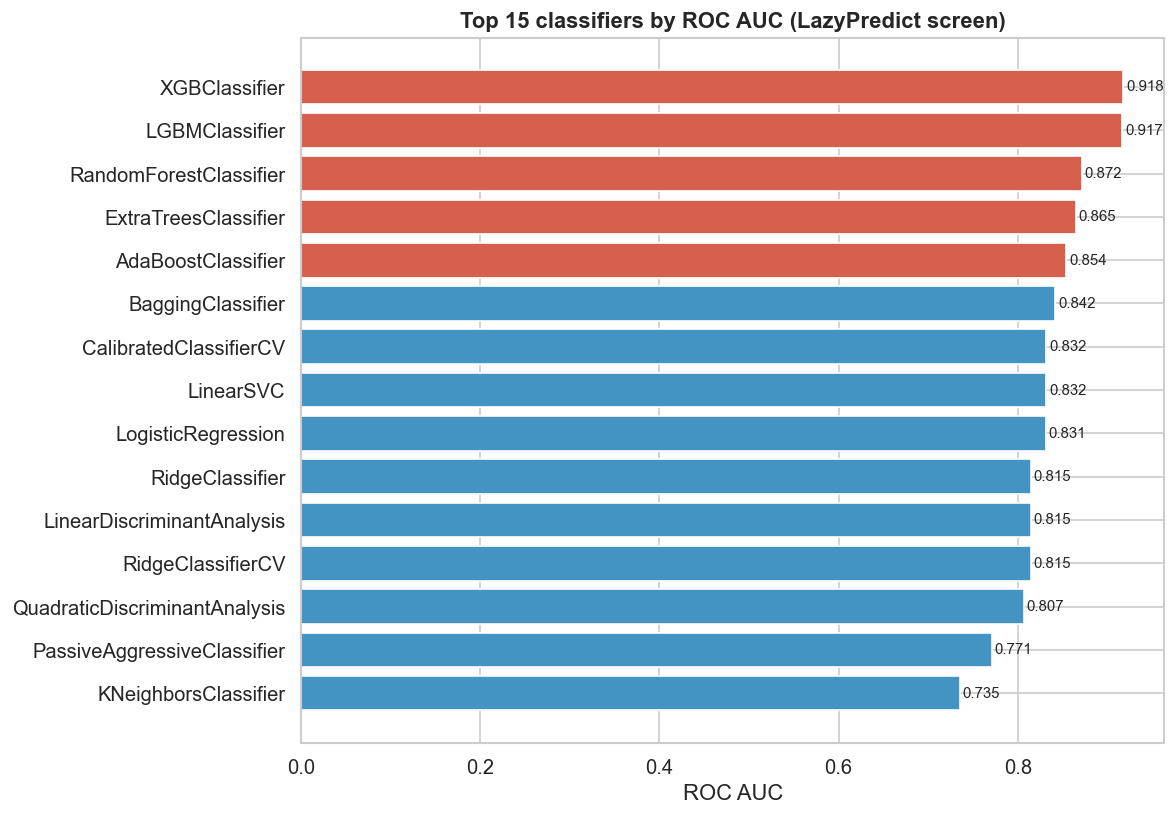

In [3]:
top = models_lz.head(15)
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d6604d' if i < 5 else '#4393c3' for i in range(len(top))]
ax.barh(range(len(top)), top['ROC AUC'].values, color=colors, edgecolor='white')
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index)
ax.invert_yaxis(); ax.set_xlabel('ROC AUC')
ax.set_title('Top 15 classifiers by ROC AUC (LazyPredict screen)', fontweight='bold')
for i, v in enumerate(top['ROC AUC'].values):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('../notebooks/plots/12_lazypredict_ranking.png', bbox_inches='tight'); plt.show()

**Takeaway:** Gradient boosting leads — **XGBoost** and **LightGBM** top the table, with the tree ensembles (RandomForest, ExtraTrees) just behind and linear models trailing — confirming the fire signal is non-linear and interaction-heavy. These scores are on the *balanced* subsample, so read them as a **ranking of families, not final accuracy**. We carry four models into honest full-data evaluation next: LogisticRegression (interpretable baseline), RandomForest, XGBoost, LightGBM.

## 3. Baselines + Honest Evaluation

Now we train the four models on the **full** 2018–2019 data and evaluate on the **full 2020 test set** at its true **0.31% prevalence**. The imbalance needs model-specific handling:

- *LogisticRegression / RandomForest* → `class_weight='balanced'`
- *XGBoost* → `scale_pos_weight` = neg/pos ratio
- *LightGBM* → **unweighted on purpose.** At a 394:1 ratio, weighting makes LightGBM's leaf-wise growth chase the sparse positives and its ROC AUC collapses (~0.91 → 0.77). We leave it unweighted and handle the operating point via the score instead.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f'Imbalance neg:pos = {neg:,}:{pos:,}  (scale_pos_weight = {spw:.0f})')

models = {
    'LogisticRegression': make_pipeline(StandardScaler(),
        LogisticRegression(class_weight='balanced', max_iter=1000)),
    'RandomForest': RandomForestClassifier(n_estimators=150, min_samples_leaf=50,
        max_features='sqrt', class_weight='balanced_subsample', n_jobs=-1, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
        tree_method='hist', eval_metric='aucpr', n_jobs=-1, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=400, max_depth=6, num_leaves=31,
        learning_rate=0.05, colsample_bytree=0.8, n_jobs=-1, random_state=42, verbose=-1),
}

proba, fitted = {}, {}
for name, m in models.items():
    t = time.time(); m.fit(X_train, y_train)
    proba[name] = m.predict_proba(X_test)[:, 1]; fitted[name] = m
    print(f'{name:18s} trained in {time.time()-t:5.1f}s')

Imbalance neg:pos = 2,670,865:6,775  (scale_pos_weight = 394)


LogisticRegression trained in   4.9s


RandomForest       trained in 104.2s


XGBoost            trained in  13.4s


LightGBM           trained in  15.7s


### Why PR-AUC, not accuracy or ROC AUC
With 0.31% positives, a model can score 99.7% accuracy by predicting "no fire" everywhere, and ROC AUC looks flattering too. **Precision–Recall AUC** is the honest summary: its no-skill baseline equals the prevalence (~0.003), so any lift above that is real signal. We rank by PR-AUC and report ROC AUC alongside.

In [5]:
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
                             f1_score, precision_score, recall_score, confusion_matrix, roc_curve)

rows, best_thr = [], {}
for name, p in proba.items():
    prec, rec, thr = precision_recall_curve(y_test, p)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    j = np.nanargmax(f1s[:-1]); best_thr[name] = thr[j]
    yhat = (p >= thr[j]).astype(int)
    rows.append({'Model': name, 'ROC AUC': roc_auc_score(y_test, p),
                 'PR AUC': average_precision_score(y_test, p),
                 'Precision@F1': precision_score(y_test, yhat, zero_division=0),
                 'Recall@F1': recall_score(y_test, yhat), 'F1': f1_score(y_test, yhat)})
results = pd.DataFrame(rows).sort_values('PR AUC', ascending=False).reset_index(drop=True)
print(f'No-skill PR-AUC baseline (prevalence) = {y_test.mean():.4f}\n')
results.round(4)

No-skill PR-AUC baseline (prevalence) = 0.0031



,Model,ROC AUC,PR AUC,Precision@F1,Recall@F1,F1
0,XGBoost,0.9205,0.0567,0.1060,0.1481,0.1236
1,LightGBM,0.9081,0.0381,0.0760,0.2081,0.1114
2,RandomForest,0.8808,0.0358,0.0665,0.1407,0.0903
3,LogisticRegression,0.8261,0.0096,0.0113,0.4578,0.0220


**Takeaway:** **XGBoost wins** — highest PR-AUC and ROC AUC — with LightGBM close, RandomForest behind, and LogisticRegression last, matching the screening. The gap between a strong ROC AUC (~0.92) and a low PR-AUC (~0.06) *is the story*: calling a specific 10 km cell on a specific day is intrinsically hard because most fire-favourable days never ignite.

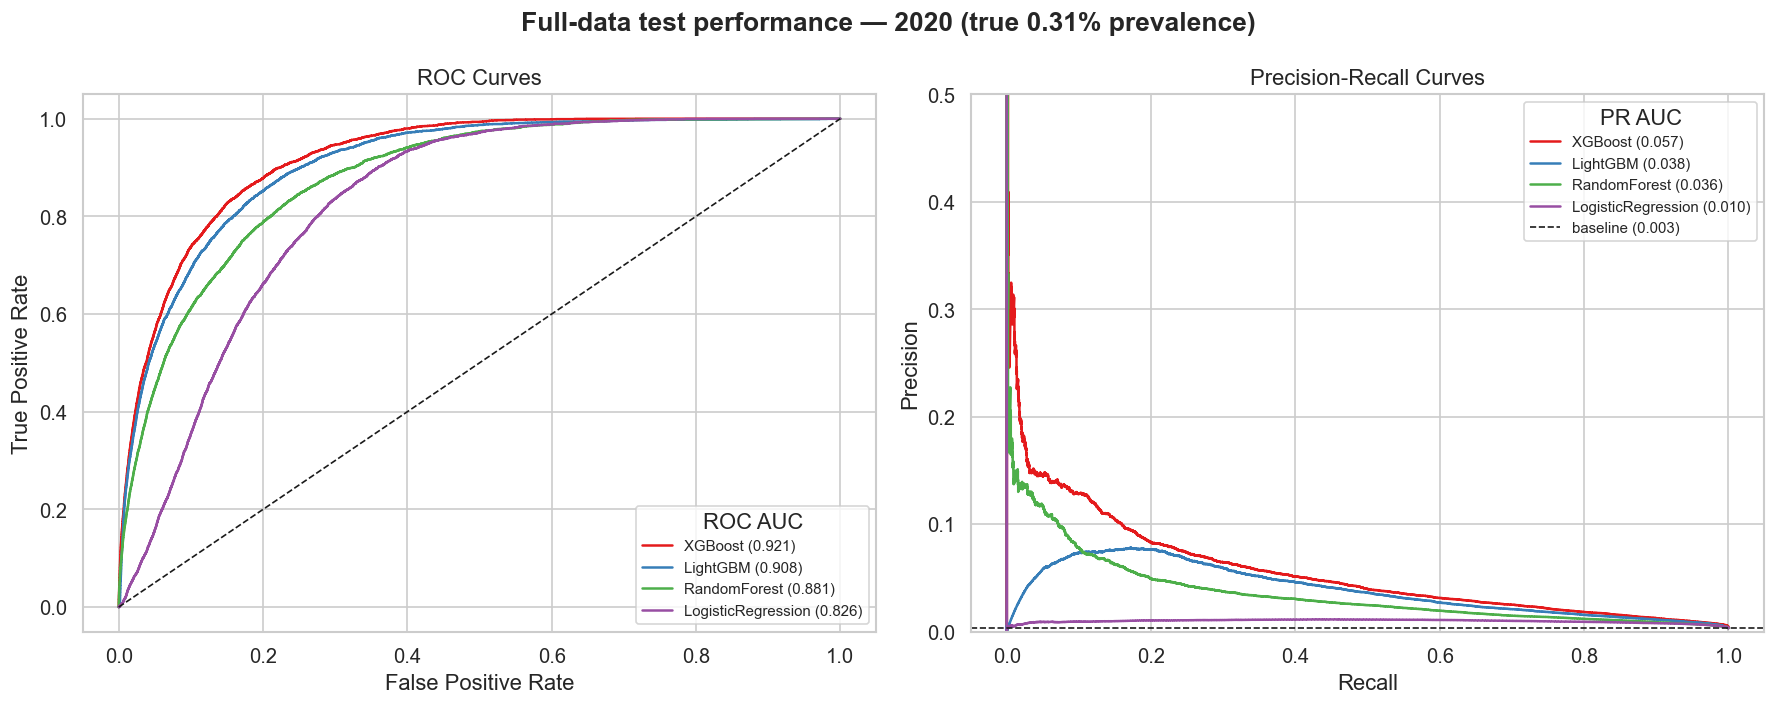

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = dict(zip(results['Model'], sns.color_palette('Set1', len(proba))))
for name in results['Model']:
    p = proba[name]; fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, color=palette[name], label=f'{name} ({roc_auc_score(y_test, p):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curves')
axes[0].legend(loc='lower right', fontsize=9, title='ROC AUC')
for name in results['Model']:
    p = proba[name]; prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, color=palette[name], label=f'{name} ({average_precision_score(y_test, p):.3f})')
axes[1].axhline(y_test.mean(), color='k', ls='--', lw=1, label=f'baseline ({y_test.mean():.3f})')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curves', ylim=(0, 0.5))
axes[1].legend(loc='upper right', fontsize=9, title='PR AUC')
plt.suptitle('Full-data test performance — 2020 (true 0.31% prevalence)', fontweight='bold')
plt.tight_layout(); plt.savefig('../notebooks/plots/13_roc_pr_curves.png', bbox_inches='tight'); plt.show()

### Why a ranker, not a hard classifier
To act on a yes/no we would pick a threshold. The confusion matrix below (XGBoost at its F1-optimal cut) and the operating-points table show the problem: catching most fires forces a flood of false alarms. The model's value is **ranking** risk, not drawing a clean line — which is exactly what the risk map in §5 uses.

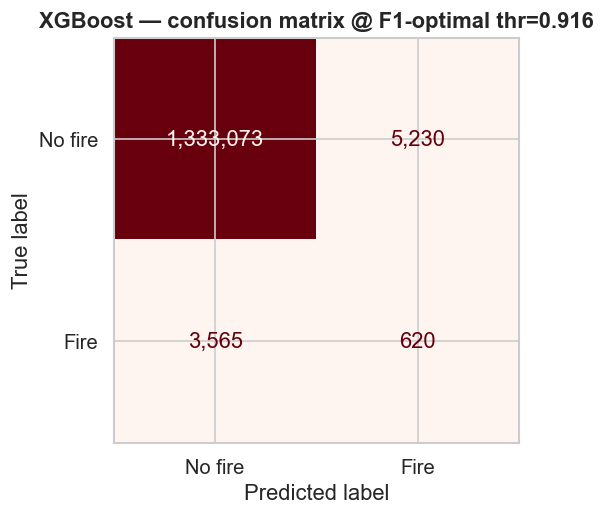

XGBoost operating points (~3,678 cells scored/day):

target recall |    thr | precision | false alarms/day
         60% |  0.723 |     3.1% |              214
         70% |  0.644 |     2.5% |              314
         80% |  0.522 |     1.8% |              497


In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
best = results.iloc[0]['Model']; p = proba[best]
yhat = (p >= best_thr[best]).astype(int)
cm = confusion_matrix(y_test, yhat)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=['No fire', 'Fire']).plot(
    ax=ax, cmap='Reds', colorbar=False, values_format=',')
ax.set_title(f'{best} — confusion matrix @ F1-optimal thr={best_thr[best]:.3f}', fontweight='bold')
plt.tight_layout(); plt.savefig('../notebooks/plots/14_confusion_matrix.png', bbox_inches='tight'); plt.show()

prec, rec, thr = precision_recall_curve(y_test, p)
print(f'{best} operating points (~{len(y_test)//365:,} cells scored/day):\n')
print(f'{"target recall":>13} | {"thr":>6} | {"precision":>9} | {"false alarms/day":>16}')
for tgt in (0.60, 0.70, 0.80):
    j = np.where(rec[:-1] >= tgt)[0][-1]
    tn, fp, fn, tp = confusion_matrix(y_test, (p >= thr[j]).astype(int)).ravel()
    print(f'{tgt:>12.0%} | {thr[j]:>6.3f} | {tp/(tp+fp):>8.1%} | {fp/365:>16.0f}')

**Takeaway:** At its F1-optimal threshold XGBoost catches only a small share of fires, and pushing to 70–80% recall drops precision to ~2–3% — hundreds of false alarms a day. As a hard classifier it is weak; as a **risk ranker** it is strong. So we tune it for ranking (§4) and turn its scores into a calibrated risk map (§5).

## 4. Hyperparameter Tuning (Optuna)

We tune the winner, XGBoost, optimising directly for **PR-AUC** on a **temporal** sub-split (train 2018 → validate 2019; 2020 stays untouched). Two design choices:

- **The right tool.** `scale_pos_weight` is one knob but it interacts with depth, regularisation and `max_delta_step`, and PR-AUC is noisy and non-convex — so instead of a grid we use **Optuna** (TPE Bayesian search) over all knobs jointly.
- **Speed.** Each trial is a full XGBoost fit, so the search trains on a **prevalence-preserving 30% subsample of 2018** and validates on all of 2019; the chosen params are then **refit on the full 2018–2019 set**.

First, a diagnostic: *does `scale_pos_weight` even move PR-AUC?*

  scale_pos_weight=   1 -> 2019 PR-AUC 0.0356


  scale_pos_weight=   5 -> 2019 PR-AUC 0.0331


  scale_pos_weight=  20 -> 2019 PR-AUC 0.0326


  scale_pos_weight=  50 -> 2019 PR-AUC 0.0311


  scale_pos_weight= 100 -> 2019 PR-AUC 0.0288


  scale_pos_weight= 200 -> 2019 PR-AUC 0.0275


  scale_pos_weight= 394 -> 2019 PR-AUC 0.0248


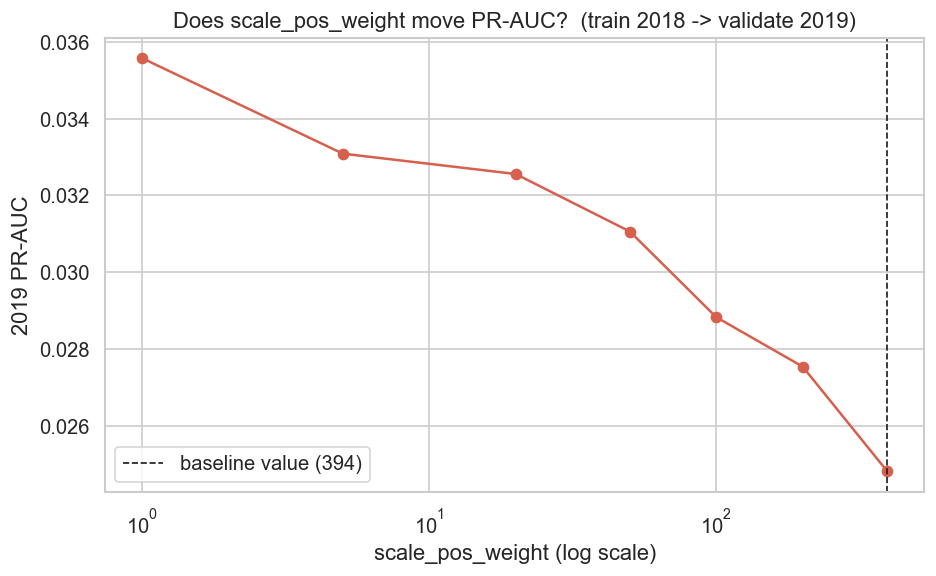

In [8]:
tr18 = train[train['date'].dt.year == 2018]
tr19 = train[train['date'].dt.year == 2019]
X18, y18 = tr18[feature_cols], tr18['has_fire']
X19, y19 = tr19[feature_cols], tr19['has_fire']

spw_grid = [1, 5, 20, 50, 100, 200, int(spw)]
spw_pr = []
for w in spw_grid:
    m = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
                      colsample_bytree=0.8, scale_pos_weight=w, tree_method='hist',
                      eval_metric='aucpr', n_jobs=-1, random_state=42)
    m.fit(X18, y18)
    spw_pr.append(average_precision_score(y19, m.predict_proba(X19)[:, 1]))
    print(f'  scale_pos_weight={w:>4} -> 2019 PR-AUC {spw_pr[-1]:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(spw_grid, spw_pr, 'o-', color='#d6604d')
ax.axvline(spw, color='k', ls='--', lw=1, label=f'baseline value ({spw:.0f})')
ax.set_xscale('log')
ax.set(xlabel='scale_pos_weight (log scale)', ylabel='2019 PR-AUC',
       title='Does scale_pos_weight move PR-AUC?  (train 2018 -> validate 2019)')
ax.legend(); plt.tight_layout()
plt.savefig('../notebooks/plots/15_spw_sweep.png', bbox_inches='tight'); plt.show()

**Takeaway:** Far from flat — 2019 PR-AUC **declines monotonically** as `scale_pos_weight` rises, from **0.036 at weight = 1** down to **0.025 at the baseline's 394**. So the heavy weighting we inherited was actively *hurting* both the ranking and (as §5 shows) the calibration. Here the knob genuinely matters, and the answer is "smaller is better" — the opposite of the usual instinct to crank it up to the class ratio. Optuna confirms this next, landing near the low end.

### Bayesian search
Optuna's TPE sampler proposes parameter sets, learns from each trial's 2019 PR-AUC, and steers toward promising regions. Each trial uses **early stopping on `aucpr`** (so `n_estimators` is chosen automatically). The space spans the imbalance knobs (`scale_pos_weight`, `max_delta_step`), tree complexity (`max_depth`, `min_child_weight`, `gamma`), row/column sampling, and L1/L2 regularisation.

Ran 50 trials in 1693s  |  best 2019 PR-AUC = 0.0263

Best params:
  learning_rate      0.03329
  max_depth          8
  min_child_weight   5.073
  gamma              0.1192
  subsample          0.8006
  colsample_bytree   0.7746
  reg_lambda         3.464
  reg_alpha          0.02903
  scale_pos_weight   4.945
  max_delta_step     4
  n_estimators       296


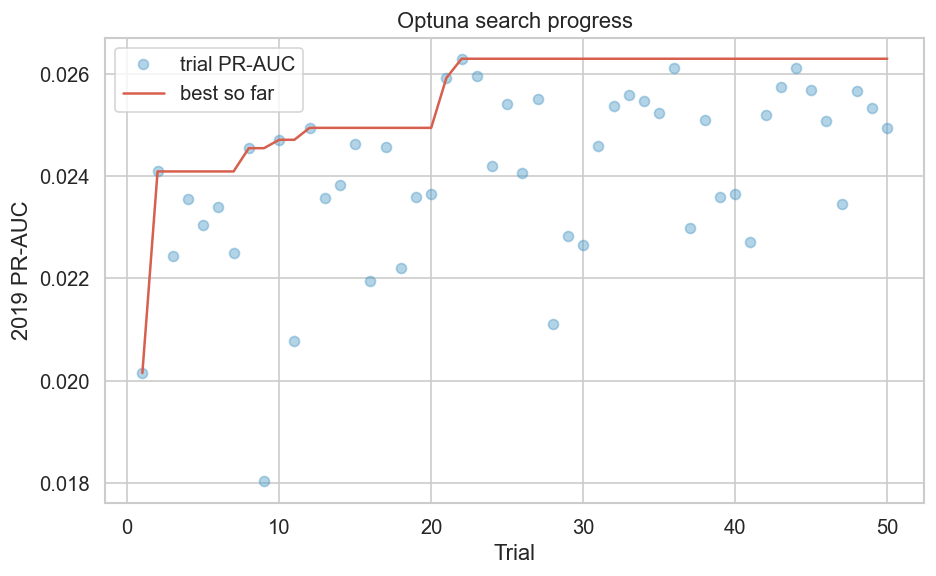

In [9]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# prevalence-preserving subsample of 2018 for fast trials
tune = tr18.sample(frac=0.3, random_state=42)
X18s, y18s = tune[feature_cols], tune['has_fire']

def objective(trial):
    params = dict(
        learning_rate=trial.suggest_float('learning_rate', 0.02, 0.2, log=True),
        max_depth=trial.suggest_int('max_depth', 3, 9),
        min_child_weight=trial.suggest_float('min_child_weight', 1, 30, log=True),
        gamma=trial.suggest_float('gamma', 1e-3, 5.0, log=True),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 1.0, 30.0, log=True),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        scale_pos_weight=trial.suggest_float('scale_pos_weight', 1.0, 400.0, log=True),
        max_delta_step=trial.suggest_int('max_delta_step', 0, 10),
    )
    m = XGBClassifier(**params, n_estimators=1500, tree_method='hist', eval_metric='aucpr',
                      early_stopping_rounds=40, n_jobs=-1, random_state=42)
    m.fit(X18s, y18s, eval_set=[(X19, y19)], verbose=False)
    trial.set_user_attr('best_iteration', int(m.best_iteration))
    return average_precision_score(y19, m.predict_proba(X19)[:, 1])

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
t0 = time.time(); study.optimize(objective, n_trials=50)
print(f'Ran {len(study.trials)} trials in {time.time()-t0:.0f}s  |  best 2019 PR-AUC = {study.best_value:.4f}\n')
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k:18s} {v:.4g}' if isinstance(v, float) else f'  {k:18s} {v}')
print(f'  {"n_estimators":18s} {study.best_trial.user_attrs["best_iteration"]+1}')

vals = [t.value for t in study.trials]
best_curve = np.maximum.accumulate(vals)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(vals)+1), vals, 'o', alpha=0.4, color='#4393c3', label='trial PR-AUC')
ax.plot(range(1, len(vals)+1), best_curve, '-', color='#d6604d', label='best so far')
ax.set(xlabel='Trial', ylabel='2019 PR-AUC', title='Optuna search progress')
ax.legend(); plt.tight_layout()
plt.savefig('../notebooks/plots/16_optuna_history.png', bbox_inches='tight'); plt.show()

**Takeaway:** Across 50 trials Optuna settles on `scale_pos_weight ≈ 4.9` (low again, echoing the sweep), `max_depth = 8`, `max_delta_step = 4`, `min_child_weight ≈ 5`, `reg_lambda ≈ 3.5`, learning rate ≈ 0.033, and 296 trees — a deeper but well-regularised model with gentle positive weighting. (Its best *validation* PR-AUC runs lower than the sweep because trials train on the 30% subsample, so the two aren't directly comparable — the real verdict is the full-data refit on 2020 next.)

Refit tuned model with n_estimators=296

             Model  ROC AUC  PR AUC
XGBoost (baseline)   0.9205  0.0567
   XGBoost (tuned)   0.9184  0.0667


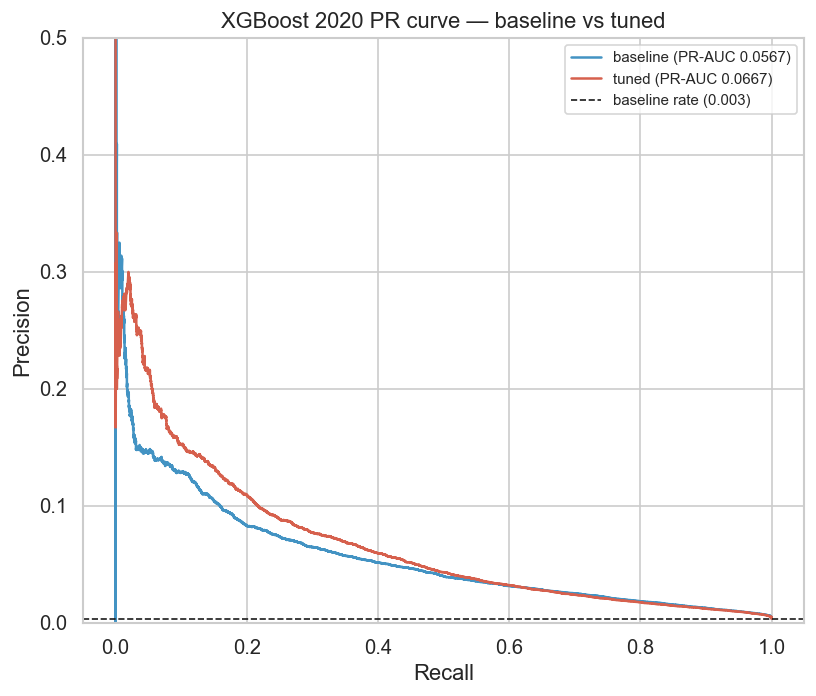

In [10]:
bp = dict(study.best_params); n_best = study.best_trial.user_attrs['best_iteration'] + 1
xgb_tuned = XGBClassifier(**bp, n_estimators=n_best, tree_method='hist', eval_metric='aucpr',
                          n_jobs=-1, random_state=42)
xgb_tuned.fit(X_train, y_train)
proba['XGBoost (tuned)'] = xgb_tuned.predict_proba(X_test)[:, 1]
fitted['XGBoost (tuned)'] = xgb_tuned

base_p, tuned_p = proba['XGBoost'], proba['XGBoost (tuned)']
cmp = pd.DataFrame({'Model': ['XGBoost (baseline)', 'XGBoost (tuned)'],
    'ROC AUC': [roc_auc_score(y_test, base_p), roc_auc_score(y_test, tuned_p)],
    'PR AUC':  [average_precision_score(y_test, base_p), average_precision_score(y_test, tuned_p)]})
print(f'Refit tuned model with n_estimators={n_best}\n')
print(cmp.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 6))
for name, pp, c in [('baseline', base_p, '#4393c3'), ('tuned', tuned_p, '#d6604d')]:
    prec, rec, _ = precision_recall_curve(y_test, pp)
    ax.plot(rec, prec, color=c, label=f'{name} (PR-AUC {average_precision_score(y_test, pp):.4f})')
ax.axhline(y_test.mean(), color='k', ls='--', lw=1, label=f'baseline rate ({y_test.mean():.3f})')
ax.set(xlabel='Recall', ylabel='Precision', title='XGBoost 2020 PR curve — baseline vs tuned', ylim=(0, 0.5))
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.savefig('../notebooks/plots/17_tuned_vs_baseline_pr.png', bbox_inches='tight'); plt.show()

**Takeaway:** Tuning lifts 2020 **PR-AUC from 0.057 → 0.067 (+18%)** while ROC AUC holds at ~0.92 (0.921 → 0.918). A real, worthwhile gain — driven mostly by dropping the extreme `scale_pos_weight` and adding regularisation — though, as anticipated, not transformational: PR-AUC is rank-based and ultimately bounded by the signal in the current features. The tuned model is what we carry into the risk map (§5), and its far gentler weighting also leaves it much better-calibrated out of the box. The next big lever is richer data (MERRA-2), not more tuning.

### What drives the tuned model?
Gain-based feature importances for the model we ship — a cross-check against the EDA.

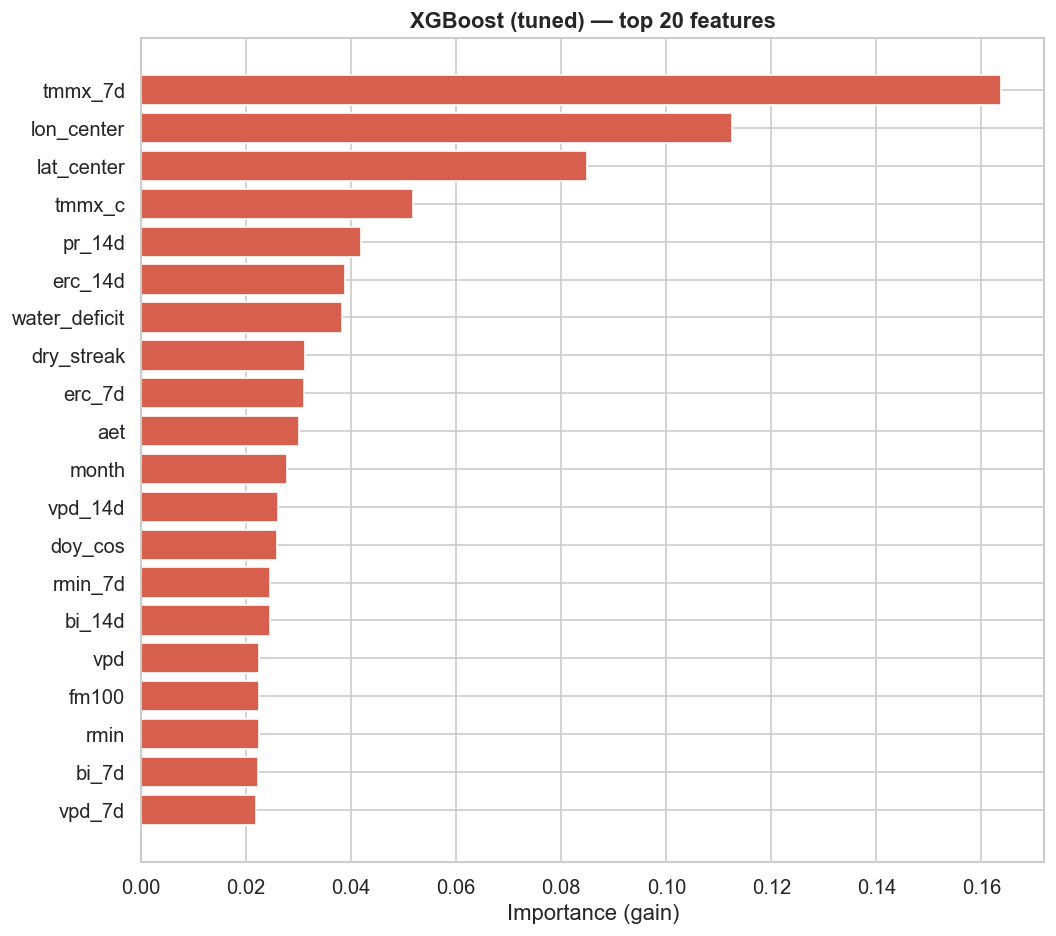

tmmx_7d          0.163804
lon_center       0.112558
lat_center       0.084975
tmmx_c           0.051732
pr_14d           0.041951
erc_14d          0.038795
water_deficit    0.038184
dry_streak       0.031164
erc_7d           0.030951
aet              0.030116
month            0.027822
vpd_14d          0.025974
dtype: float32

In [11]:
imp = pd.Series(xgb_tuned.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 8)); top = imp.head(20)
ax.barh(range(len(top)), top.values, color='#d6604d', edgecolor='white')
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index); ax.invert_yaxis()
ax.set_xlabel('Importance (gain)')
ax.set_title('XGBoost (tuned) — top 20 features', fontweight='bold')
plt.tight_layout(); plt.savefig('../notebooks/plots/18_feature_importance.png', bbox_inches='tight'); plt.show()
imp.head(12)

**Takeaway:** The drivers line up with the EDA. **7-day max temperature** (`tmmx_7d`) is the single strongest signal, followed by **location** (`lon_center`, `lat_center` — the model leaning on California's fire geography), then **dryness and fire-danger** indices (`pr_14d`, `erc_14d`, `water_deficit`, `dry_streak`, `erc_7d`, `vpd_14d`) and **seasonality** (`month`). Antecedent heat and dryness — the rolling 7d/14d windows, not any single instantaneous reading — carry the weight, which is exactly why those features earn their place.

## 5. From Probabilities to a Risk Map

We take the **tuned** XGBoost and turn it into the dashboard's red/yellow/green layer in two steps:

1. **Calibrate** — boosting with class weighting distorts the raw scores (a "0.5" is not a 50% chance of fire). Isotonic regression remaps them so a stated risk of *X%* corresponds to an *X%* real fire rate.
2. **Tier on recall-target thresholds** — colour cells by calibrated risk using cutoffs chosen to hit operational *recall* goals (catch ~90% of fires in the watch tier, ~60% in act-now) — not arbitrary percentages, and not relative ranking, so a calm day still stays green.

### Step 1 — Calibrate the tuned model's scores
We fit the calibrator on one half of 2020 and check it on the *other* half, so the reliability check is honest. The diagram plots predicted risk against the fire rate that actually occurred — a perfectly calibrated model sits on the diagonal.

Calibrating XGBoost (tuned) via isotonic regression
  fit on 671,244 cell-days, evaluated on 671,244 held-out cell-days

              mean predicted   actual rate       Brier
raw                   0.0111        0.0031     0.00331
calibrated            0.0031        0.0031     0.00299


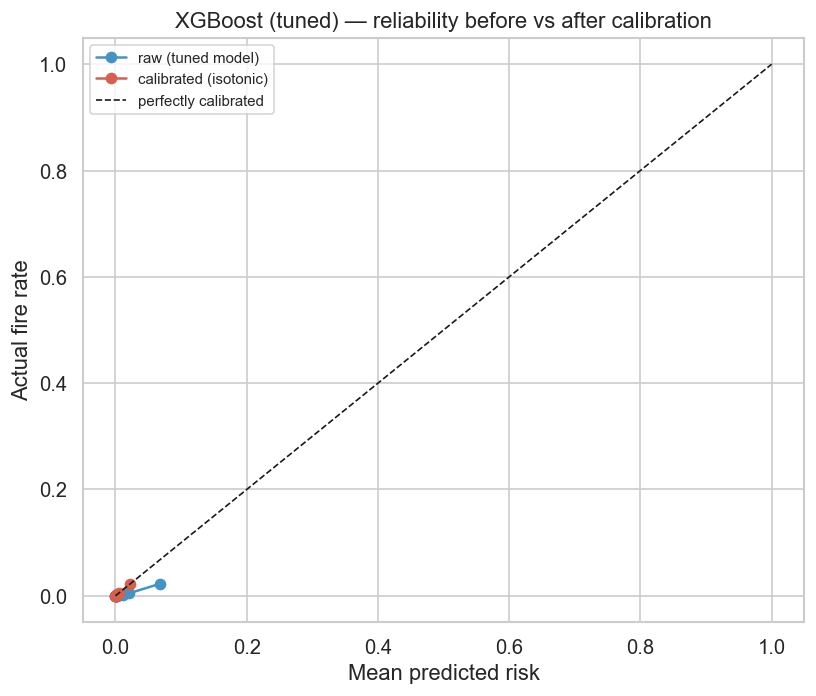

In [12]:
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

best = 'XGBoost (tuned)'
raw = proba[best]
y_arr = y_test.to_numpy()

cal_idx, val_idx = train_test_split(
    np.arange(len(y_arr)), test_size=0.5, stratify=y_arr, random_state=42)
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(raw[cal_idx], y_arr[cal_idx])
raw_val, y_val = raw[val_idx], y_arr[val_idx]
cal_val = iso.transform(raw_val)

print(f'Calibrating {best} via isotonic regression')
print(f'  fit on {len(cal_idx):,} cell-days, evaluated on {len(val_idx):,} held-out cell-days\n')
print(f'{"":12}{"mean predicted":>16}{"actual rate":>14}{"Brier":>12}')
for label, pp in [('raw', raw_val), ('calibrated', cal_val)]:
    print(f'{label:12}{pp.mean():>16.4f}{y_val.mean():>14.4f}{brier_score_loss(y_val, pp):>12.5f}')

fig, ax = plt.subplots(figsize=(7, 6))
for label, pp, color in [('raw (tuned model)', raw_val, '#4393c3'),
                         ('calibrated (isotonic)', cal_val, '#d6604d')]:
    frac_pos, mean_pred = calibration_curve(y_val, pp, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 'o-', color=color, label=label)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='perfectly calibrated')
ax.set(xlabel='Mean predicted risk', ylabel='Actual fire rate',
       title=f'{best} — reliability before vs after calibration')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.savefig('../notebooks/plots/19_calibration.png', bbox_inches='tight'); plt.show()

**Takeaway:** Because Optuna chose a gentle `scale_pos_weight ≈ 4.9`, the tuned model is only ~**3.6× over-confident** (raw mean 0.011 vs the true 0.31% rate) — versus ~60× for the original weight-394 baseline. Isotonic calibration still tightens it: the mean prediction snaps onto **0.0031 (exact)** and the Brier score improves to 0.0030. A calibrated "4%" now genuinely means *about 4 of every 100 such cell-days ignite* — the honest numbers we threshold below. Tuning and calibration reinforced each other here.

### Step 2 — Red / yellow / green tiers (recall-target cutoffs)
Rather than arbitrary percentages, we set the tier boundaries from **recall goals** on held-out data — reflecting the operational priority that a *missed* fire costs far more than a false alarm:

- 🟡 **Yellow (watch)** — the cutoff that catches ~**90%** of fires
- 🔴 **Red (act now)** — the stricter cutoff that catches ~**60%** of fires
- 🟢 **Green** — everything below the yellow cutoff

We derive the cutoffs on the calibration half and validate on the held-out half, reporting the **false-alarms/day** cost of each so the recall ↔ workload tradeoff is explicit. Because they are absolute (not relative) cutoffs, a calm day leaves the whole state green; and they are config dials — changeable without retraining.

Recall-target cutoffs (calibrated risk):  Red >= 0.0127 (~60% recall)  |  Yellow >= 0.0023 (~90% recall)

Statewide baseline fire rate: 0.3117%  (held-out 2020 half)

         cells  fires  fire_rate  pct_of_fires  flagged_per_day  false_alarms_per_day
tier                                                                                 
Red      40448   1272       3.14          60.8            221.0                 214.0
Yellow  151230    685       0.45          32.7            826.0                 823.0
Green   479566    135       0.03           6.5           2621.0                2620.0

Flagged (red+yellow): 1047 cells/day, 1037 false alarms/day, catching 94% of fires


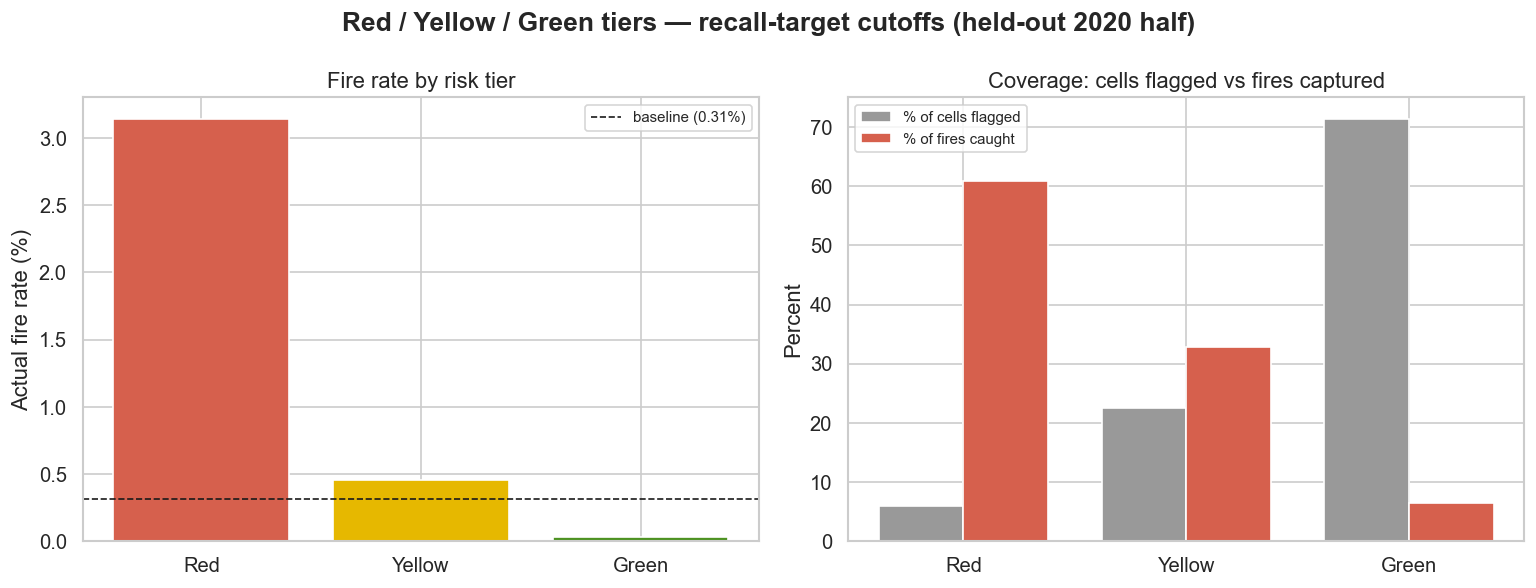

In [13]:
cal_cal = iso.transform(raw[cal_idx])
y_cal = y_arr[cal_idx]

def thr_for_recall(y, p, target):
    # highest calibrated-risk threshold that still catches >= target fraction of fires
    _, rec, thr = precision_recall_curve(y, p)
    ok = np.where(rec[:-1] >= target)[0]
    return float(thr[ok[-1]]) if len(ok) else 0.0

YELLOW_T = thr_for_recall(y_cal, cal_cal, 0.90)
RED_T    = thr_for_recall(y_cal, cal_cal, 0.60)
print(f'Recall-target cutoffs (calibrated risk):  Red >= {RED_T:.4f} (~60% recall)  |  '
      f'Yellow >= {YELLOW_T:.4f} (~90% recall)\n')

tier_colors = {'Red': '#d6604d', 'Yellow': '#e6b800', 'Green': '#4d9221'}
def to_tier(p):
    return np.where(p >= RED_T, 'Red', np.where(p >= YELLOW_T, 'Yellow', 'Green'))

base = y_arr.mean()
n_days = len(y_val) / 3668
tdf = pd.DataFrame({'tier': to_tier(cal_val), 'fire': y_val})
tier_summary = (tdf.groupby('tier')
                  .agg(cells=('fire', 'size'), fires=('fire', 'sum'), fire_rate=('fire', 'mean'))
                  .reindex(['Red', 'Yellow', 'Green']).fillna(0))
tier_summary['pct_of_fires'] = tier_summary['fires'] / tier_summary['fires'].sum()
tier_summary['flagged_per_day'] = tier_summary['cells'] / n_days
tier_summary['false_alarms_per_day'] = (tier_summary['cells'] - tier_summary['fires']) / n_days

print(f'Statewide baseline fire rate: {base:.4%}  (held-out 2020 half)\n')
print(tier_summary.assign(fire_rate=lambda d: (d.fire_rate*100).round(2),
                          pct_of_fires=lambda d: (d.pct_of_fires*100).round(1),
                          flagged_per_day=lambda d: d.flagged_per_day.round(0),
                          false_alarms_per_day=lambda d: d.false_alarms_per_day.round(0)).to_string())
flagged = tier_summary.loc[['Red', 'Yellow']]
print(f"\nFlagged (red+yellow): {flagged['flagged_per_day'].sum():.0f} cells/day, "
      f"{flagged['false_alarms_per_day'].sum():.0f} false alarms/day, "
      f"catching {flagged['pct_of_fires'].sum()*100:.0f}% of fires")

order = ['Red', 'Yellow', 'Green']; cols = [tier_colors[t] for t in order]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(order, tier_summary['fire_rate'].values * 100, color=cols, edgecolor='white')
axes[0].axhline(base * 100, color='k', ls='--', lw=1, label=f'baseline ({base*100:.2f}%)')
axes[0].set(ylabel='Actual fire rate (%)', title='Fire rate by risk tier'); axes[0].legend(fontsize=9)
x = np.arange(len(order)); w = 0.38
axes[1].bar(x - w/2, tier_summary['cells'].values / tier_summary['cells'].sum() * 100, w,
            label='% of cells flagged', color='#999999', edgecolor='white')
axes[1].bar(x + w/2, tier_summary['pct_of_fires'].values * 100, w,
            label='% of fires caught', color='#d6604d', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(order)
axes[1].set(ylabel='Percent', title='Coverage: cells flagged vs fires captured'); axes[1].legend(fontsize=9)
plt.suptitle('Red / Yellow / Green tiers — recall-target cutoffs (held-out 2020 half)', fontweight='bold')
plt.tight_layout(); plt.savefig('../notebooks/plots/20_risk_tiers.png', bbox_inches='tight'); plt.show()

**Takeaway:** The recall-target cutoffs deliver exactly the operating point we chose: **red + yellow catch 94% of fires** while flagging ~**1,047 cells/day** (≈29% of the state), at a cost of ~**1,037 false alarms/day** — the explicit price of minimising misses. Red alone (221 cells/day) ignites at **3.14%, ~10× baseline**, capturing 61% of fires; **green now holds just 6.5% of fires** despite covering ~70% of the map. The false-alarm column is the dial: tighten the recall targets to shrink the workload, loosen them to miss even fewer fires. And because the cutoffs are absolute, a calm day still leaves the whole state green.

### Step 3 — A risk map for the worst day of 2020
A preview of the dashboard's core view: every ~10 km California cell on the single worst fire day of 2020, coloured by its calibrated risk tier, with black ✕ marks where fires actually broke out. This is the exact layer the live dashboard will render each day.

Peak fire day in 2020: 2020-07-04  —  91 cells ignited


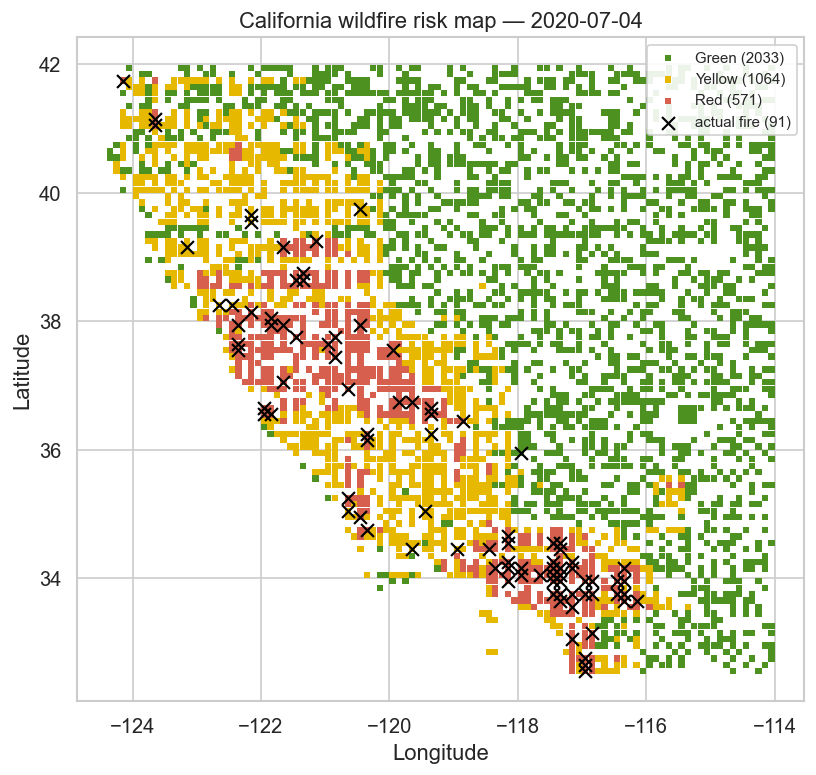

In [14]:
test_map = test[['grid_id', 'date', 'lat_center', 'lon_center', 'has_fire']].copy()
test_map['risk'] = iso.transform(raw)
test_map['tier'] = to_tier(test_map['risk'].to_numpy())

peak_day = test_map.groupby('date')['has_fire'].sum().idxmax()
day = test_map[test_map['date'] == peak_day]
print(f'Peak fire day in 2020: {peak_day.date()}  —  {int(day["has_fire"].sum())} cells ignited')

fig, ax = plt.subplots(figsize=(7, 8))
for t in ['Green', 'Yellow', 'Red']:
    sub = day[day['tier'] == t]
    ax.scatter(sub['lon_center'], sub['lat_center'], s=14, marker='s',
               c=tier_colors[t], label=f'{t} ({len(sub)})', edgecolors='none')
fired = day[day['has_fire'] == 1]
ax.scatter(fired['lon_center'], fired['lat_center'], s=60, marker='x',
           c='black', linewidths=1.3, label=f'actual fire ({len(fired)})')
ax.set(xlabel='Longitude', ylabel='Latitude', title=f'California wildfire risk map — {peak_day.date()}')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout(); plt.savefig('../notebooks/plots/21_risk_map.png', bbox_inches='tight'); plt.show()

**Takeaway:** This is the dashboard in miniature — **July 4, 2020, California's worst fire day of the year (91 cells ignited)**. The red/yellow cells concentrate exactly where the EDA flagged danger — the Sierra foothills and Southern California mountains — and with the recall-favouring cutoffs (94% recall statewide) the large majority of the black ✕ ignitions fall inside flagged cells. The map does its job: it tells an operator *where to look first*. Wiring this same per-day computation (tuned model → calibrate → tier) into a live feed is the dashboard build (deliverable #2).

## 6. Summary & Next Steps

**Where we landed:** XGBoost is the model to carry forward. We screened algorithm families (§2), trained baselines and evaluated them honestly on 2020 (§3), tuned XGBoost with a 50-trial Optuna search optimising PR-AUC on a temporal split (§4), and turned the tuned model into a usable product (§5): isotonic **calibration** makes the scores honest probabilities, and **recall-target red/yellow/green cutoffs** produce a daily California risk map with a bounded false-alarm budget — the prototype of deliverable #2. Honest framing throughout: this is a strong risk *ranker/tracker*, not a hard classifier.

**Next:**
1. **MERRA-2 gridded PM2.5 / aerosols** integration → retrain and measure the PR-AUC lift (expected to help more than further tuning).
2. **Spatial / temporal cross-validation** — confirm 2020 (an extreme fire year) isn't skewing the estimate; refit the calibrator per fold.
3. **Productionize the risk map** — wire the tuned-model → calibrate → tier pipeline into the **live dashboard** with a real-time daily feed.
4. **Two-stage severity model** (optional) — weight risk by expected acres burned, to prioritise by consequence as well as likelihood.